## Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
X = np.array([[60, 2], [100, 4]])
y = np.array([50_000, 90_000])

for lr in [0.0000001, 0.00001, 0.001]:
    W = np.array([0.0, 0.0])
    for epoch in range(100):
        y_pred = X@W
        error = y_pred-y
        gradient = 2/len(X)*X.T@error
        W -= lr*gradient 
    mse = np.mean(error**2)
    print(f"Learning rate: {lr}, MSE: {mse:.2f}, Weights: {W}")

Learning rate: 1e-07, MSE: 4047869829.48, Weights: [112.25812334   4.3039845 ]
Learning rate: 1e-05, MSE: 5841427.73, Weights: [881.02300559  34.85890383]
Learning rate: 0.001, MSE: 540441445837611989188289251927556156548443555687497063725753092076592482881617275069222503805551517848144943295107409824635513614086723357622441686925985244743946602780933441986623832734635799988658230219685275237744568126406656.00, Weights: [-1.12341631e+113 -4.29545239e+111]


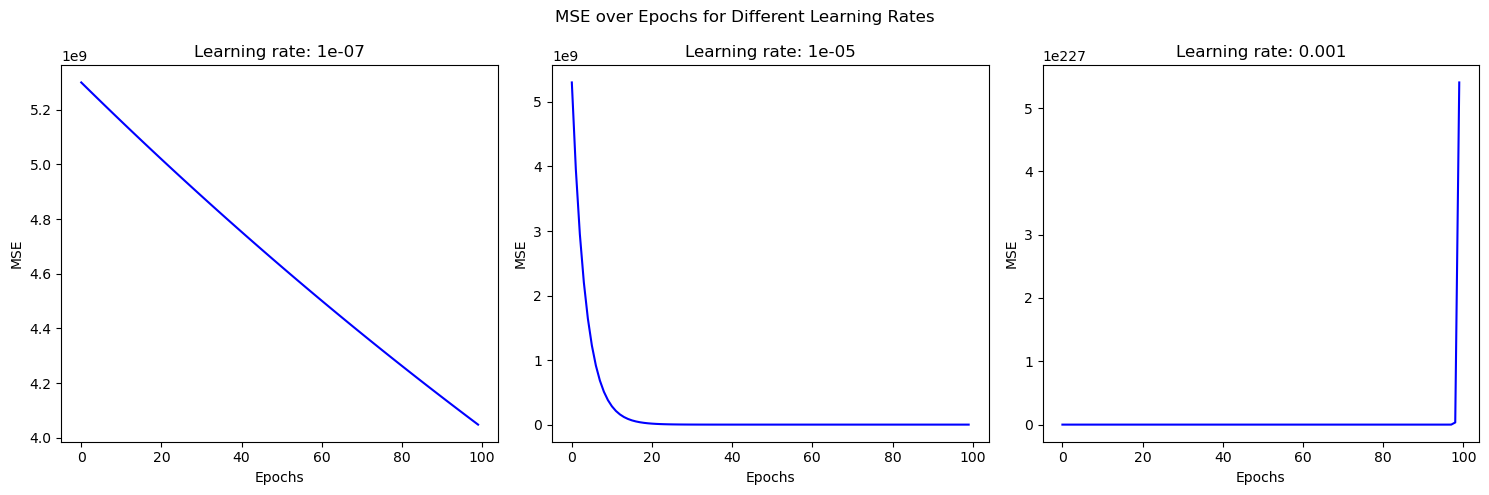

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X = np.array([[60, 2], [100, 4]])
y = np.array([50_000, 90_000])

for idx, lr in enumerate([0.0000001, 0.00001, 0.001]):
    W = np.array([0.0, 0.0])
    mse_list = []
    for epoch in range(100):
        y_pred = X@W
        error = y_pred-y
        gradient = 2/len(X)*X.T@error
        W -= lr*gradient 

        mse = np.mean(error**2)
        mse_list.append(mse)
    
    axes[idx].plot(mse_list, c='blue', label='MSE')
    axes[idx].set_title(f"Learning rate: {lr}")
    axes[idx].set_xlabel("Epochs")
    axes[idx].set_ylabel("MSE")

plt.suptitle("MSE over Epochs for Different Learning Rates")
plt.tight_layout()
plt.show()

###

Trying with gradeint descent types:

In [12]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [13]:
X_train = np.array([[100, 4], [150, 3], [200, 5], [250, 6], [300, 7]])
y_train = np.array([90_000, 120_000, 150_000, 180_000, 210_000])


# calculation without scaling
model = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01, random_state=42)
model.fit(X_train, y_train)
y_pred_us = model.predict(X_train)
error_us = y_pred_us - y_train
print(f"Without Scaling - MSE: {np.mean(error_us**2):.2f}, Weights: {model.coef_}, Intercept: {model.intercept_}")
print(f"Predictions without scaling: {y_pred_us}")
print(f"Real values: {y_train}")

Without Scaling - MSE: 187482685835071096250311901184.00, Weights: [2.04020212e+12 4.08027152e+10], Intercept: [-9.73171015e+09]
Predictions without scaling: [2.04173691e+14 3.06142994e+14 4.08234706e+14 5.10285614e+14
 6.12336523e+14]
Real values: [ 90000 120000 150000 180000 210000]


In [16]:
# calculation with scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
model.fit(X_train_s, y_train)
y_pred_s = model.predict(X_train_s)
error = y_pred_s-y_train

print(f"With Scaling - Mse:{np.mean(error**2)}, Weights: {model.coef_}, Intercept/Bias: {model.intercept_}")
print(f"Predictions with scaling: {y_pred_s.round(0)}")
print(f"Real values: {y_train}")

With Scaling - Mse:4551.146395385378, Weights: [42274.75790256   149.96104444], Intercept/Bias: [149999.90119479]
Predictions with scaling: [ 90108. 119895. 150000. 179999. 209998.]
Real values: [ 90000 120000 150000 180000 210000]


c:\Users\OsiyoComputers\anaconda\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
